# 3. Data Cleaning, Merge, and Descriptive Analysis

## Purpose

This notebook takes the raw outputs from notebooks 1 and 2:
- **COVID policy data** (national level): `data/clean/covid_policy_national.csv`
- **Air quality data** (city level, raw): `data/raw/aqicn_all_cities_raw.csv`
- **City-to-country mapping**: `data/clean/city_country_mapping.csv`

And produces a **clean, merged, analysis-ready panel dataset** at the city × date level,
along with descriptive statistics, visualizations, and data quality documentation.

## Steps

1. Load and inspect raw pollution data
2. Pivot from long to wide format
3. Missing value analysis and flagging
4. Merge with COVID policy data
5. Panel balance and coverage checks
6. Feature engineering (log transforms, time variables)
7. Descriptive statistics and summary tables
8. Visualizations (distributions, time series, correlations)
9. Save analysis-ready dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Output directory for figures
os.makedirs('../output/figures', exist_ok=True)

---
## 3.1 Load raw pollution data

The raw AQICN data is in **long format**: each row is a city × date × species
observation. The `Specie` column contains both pollutants (no2, pm25, etc.) and
weather variables (temperature, humidity, etc.). The `median` column is the
median value across all monitoring stations in that city on that day — this is
our primary measurement.

In [3]:
df_poll = pd.read_csv('../data/raw/aqicn_all_cities_raw.csv')
print(f'Shape: {df_poll.shape}')
print(f'Columns: {df_poll.columns.tolist()}')
print(f'\nDate range: {df_poll["Date"].min()} to {df_poll["Date"].max()}')
print(f'Cities: {df_poll["City"].nunique()}')
print(f'Countries: {df_poll["Country"].nunique()}')
df_poll.head()

Shape: (1340253, 9)
Columns: ['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median', 'variance']

Date range: 2019-12-30 to 2023-01-01
Cities: 126
Countries: 9


,Date,Country,City,Specie,count,min,max,median,variance
0,2020-01-20,GB,Edinburgh,co,12,0.4,1.1,0.5,0.57
1,2020-01-26,GB,Edinburgh,co,18,0.2,0.9,0.3,0.52
2,2020-02-24,GB,Edinburgh,co,18,0.2,1.0,0.6,0.47
3,2020-02-26,GB,Edinburgh,co,26,0.4,1.5,0.9,1.31
4,2020-03-14,GB,Edinburgh,co,48,0.6,1.9,1.3,0.87


---
## 3.2 Inspect available species (pollutants + weather)

We check which pollutants and weather variables are available, how many
city × date observations each has, and what their value ranges look like.
This informs which variables are usable and which to drop.

In [4]:
# Standardize species names (some quarters use hyphens, some use spaces)
df_poll['Specie'] = df_poll['Specie'].str.replace('-', ' ', regex=False).str.strip()

# Coverage per species
species_coverage = df_poll.groupby('Specie').agg(
    n_obs=('median', 'count'),
    n_non_null=('median', lambda x: x.notna().sum()),
    n_cities=('City', 'nunique'),
    median_val=('median', 'median'),
    min_val=('median', 'min'),
    max_val=('median', 'max')
).sort_values('n_non_null', ascending=False)

species_coverage['pct_non_null'] = (
    species_coverage['n_non_null'] / species_coverage['n_obs'] * 100
).round(1)

print('Species coverage (sorted by number of non-null observations):')
print(species_coverage.to_string())

Species coverage (sorted by number of non-null observations):
                n_obs  n_non_null  n_cities  median_val  min_val  max_val  pct_non_null
Specie                                                                                 
pm10           132217      132217       126        14.0      1.0    454.0         100.0
temperature    131748      131748       126        13.7    -16.0     39.0         100.0
pressure       131736      131736       126      1016.0    600.0   1265.7         100.0
humidity       131593      131593       126        75.3      0.2    100.0         100.0
wind speed     128498      128498       126         2.3      0.1    344.5         100.0
no2            125448      125448       124         6.9      0.1     58.9         100.0
o3             115696      115696       116        22.0      0.1    113.1         100.0
pm25           113624      113624       117        32.0      1.0    832.0         100.0
wind gust      106841      106841       126         5.5   

---
## 3.3 Pivot to wide format

We pivot from long format (one row per city × date × species) to **wide format**
(one row per city × date, with columns for each species). We use the `median`
value — the median across monitoring stations within a city on a given day.

After pivoting, each row is a **city-day observation** with separate columns for
NO2, PM2.5, temperature, etc.

In [5]:
df_wide = df_poll.pivot_table(
    index=['Country', 'City', 'Date'],
    columns='Specie',
    values='median'
).reset_index()

# Flatten column MultiIndex
df_wide.columns.name = None
df_wide['Date'] = pd.to_datetime(df_wide['Date'])

print(f'Wide format: {df_wide.shape[0]:,} rows × {df_wide.shape[1]} columns')
print(f'Cities: {df_wide["City"].nunique()}')
print(f'Date range: {df_wide["Date"].min().date()} to {df_wide["Date"].max().date()}')
print(f'\nColumns: {df_wide.columns.tolist()}')
df_wide.head()

Wide format: 126,475 rows × 16 columns
Cities: 126
Date range: 2019-12-30 to 2023-01-01

Columns: ['Country', 'City', 'Date', 'co', 'dew', 'humidity', 'no2', 'o3', 'pm10', 'pm25', 'precipitation', 'pressure', 'so2', 'temperature', 'wind gust', 'wind speed']


,Country,City,Date,co,dew,humidity,no2,o3,pm10,pm25,precipitation,pressure,so2,temperature,wind gust,wind speed
0,AT,Graz,2019-12-30,0.1,NaN,NaN,16.5,NaN,25.0,NaN,NaN,NaN,1.1,NaN,NaN,NaN
1,AT,Graz,2019-12-31,0.1,NaN,NaN,19.2,NaN,32.0,NaN,NaN,NaN,1.6,NaN,NaN,NaN
2,AT,Graz,2020-01-01,0.1,NaN,NaN,13.3,NaN,37.0,NaN,NaN,NaN,1.1,NaN,NaN,NaN
3,AT,Graz,2020-01-02,0.1,NaN,NaN,15.6,NaN,37.0,NaN,NaN,NaN,1.6,NaN,NaN,NaN
4,AT,Graz,2020-01-03,0.1,NaN,76.0,22.0,NaN,36.0,NaN,NaN,1024.1,1.6,-0.3,1.4,0.3


---
## 3.4 Missing value analysis

Missing values are common in air quality data: monitors go offline, data fails
quality checks, or a city simply doesn't have a monitor for a given pollutant.

We check:
1. **Overall missing rates** per variable
2. **Per-city coverage** for our primary outcome (NO2)
3. **Temporal patterns** — is missingness correlated with lockdown timing?
   (This would be a concern if monitors were shut down due to COVID.)
4. **Create missing-value flags** before any imputation, following the approach
   from our Airbnb assignment where missingness itself can be informative.

In [6]:
# Define variable groups
pollutants = ['no2', 'pm25', 'pm10', 'o3', 'co', 'so2']
weather_vars = ['temperature', 'humidity', 'pressure', 'wind speed', 'wind gust',
                'dew', 'precipitation']

# Keep only those that exist in the data
pollutants = [p for p in pollutants if p in df_wide.columns]
weather_vars = [w for w in weather_vars if w in df_wide.columns]

print(f'Pollutants available: {pollutants}')
print(f'Weather variables available: {weather_vars}')

# Overall missing rates
print(f'\n{"Variable":25s} {"Missing %":>10s} {"N non-null":>12s}')
print('-' * 50)
for col in pollutants + weather_vars:
    n_total = len(df_wide)
    n_miss = df_wide[col].isna().sum()
    pct = n_miss / n_total * 100
    print(f'{col:25s} {pct:9.1f}% {n_total - n_miss:>12,}')

Pollutants available: ['no2', 'pm25', 'pm10', 'o3', 'co', 'so2']
Weather variables available: ['temperature', 'humidity', 'pressure', 'wind speed', 'wind gust', 'dew', 'precipitation']

Variable                   Missing %   N non-null
--------------------------------------------------
no2                             6.6%      118,091
pm25                           15.4%      107,058
pm10                            1.6%      124,491
o3                             13.9%      108,911
co                             53.9%       58,340
so2                            41.6%       73,828
temperature                     2.0%      123,895
humidity                        2.2%      123,754
pressure                        2.0%      123,885
wind speed                      5.1%      120,021
wind gust                      21.1%       99,765
dew                            43.3%       71,768
precipitation                  95.4%        5,792


In [7]:
# Per-city NO2 coverage
# NO2 is the most directly traffic-related pollutant and therefore most
# responsive to lockdown-induced mobility reductions — our primary outcome.
if 'no2' in df_wide.columns:
    city_coverage = df_wide.groupby(['Country', 'City']).agg(
        n_days=('Date', 'count'),
        no2_ok=('no2', lambda x: x.notna().sum()),
        pm25_ok=('pm25', lambda x: x.notna().sum()) if 'pm25' in df_wide.columns else ('Date', 'count'),
        no2_mean=('no2', 'mean')
    ).reset_index()
    city_coverage['no2_pct'] = (city_coverage['no2_ok'] / city_coverage['n_days'] * 100).round(1)
    city_coverage = city_coverage.sort_values('no2_pct')

    print('NO2 coverage per city — WORST 20:')
    print(city_coverage.head(20).to_string(index=False))
    print(f'\nCities with <50% NO2 coverage: {(city_coverage["no2_pct"] < 50).sum()}')
    print(f'Cities with 50-70% NO2 coverage: {((city_coverage["no2_pct"] >= 50) & (city_coverage["no2_pct"] < 70)).sum()}')
    print(f'Cities with >=70% NO2 coverage: {(city_coverage["no2_pct"] >= 70).sum()}')

NO2 coverage per city — WORST 20:
Country             City  n_days  no2_ok  pm25_ok  no2_mean  no2_pct
     DE            Mainz    1005       0        0       NaN      0.0
     IT          Trieste     966       0      820       NaN      0.0
     IT            Turin     946     318      860 12.476730     33.6
     DE        Wiesbaden    1015     393      993 12.187023     38.7
     DE           Kassel     999     393      946  9.345802     39.3
     DE        Darmstadt    1000     393      993  7.909415     39.3
     BE             Gent     948     495      938  8.170505     52.2
     BE        Antwerpen     947     495      938  9.808283     52.3
     BE         Brussels     949     496      941  7.788710     52.3
     BE        Charleroi     947     496      936  8.342339     52.4
     BE            Namur     947     496      929  4.919758     52.4
     BE            Liège     947     496      938  7.247984     52.4
     FR            Lille    1000     818      696  8.325978     81.8


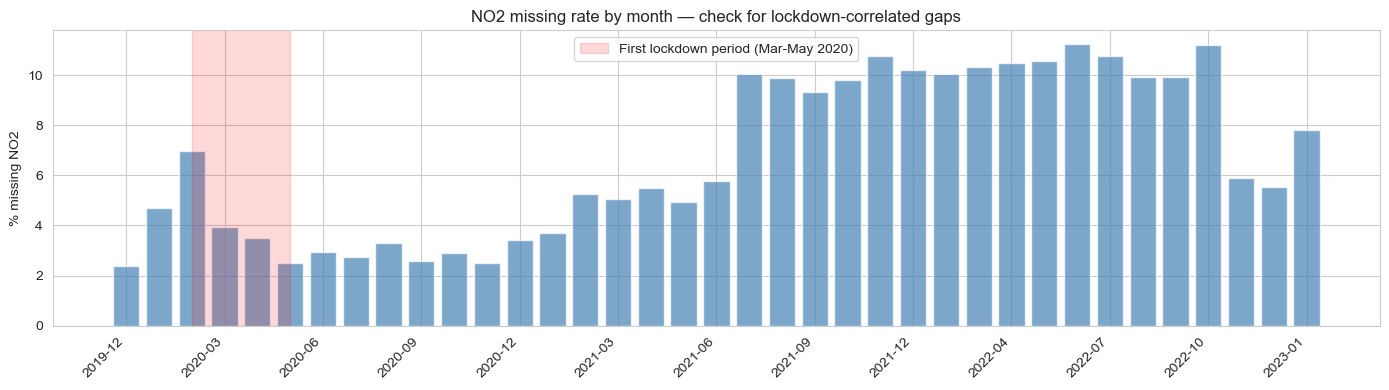

In [8]:
# Temporal pattern of missingness — check for lockdown-correlated gaps
# If NO2 is more likely missing during March-May 2020, that would bias our results.
monthly_miss = df_wide.copy()
monthly_miss['yearmonth'] = monthly_miss['Date'].dt.to_period('M').astype(str)

miss_by_month = monthly_miss.groupby('yearmonth')['no2'].apply(
    lambda x: x.isna().mean() * 100
).reset_index(name='pct_missing_no2')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(miss_by_month)), miss_by_month['pct_missing_no2'], color='steelblue', alpha=0.7)
ax.set_xticks(range(0, len(miss_by_month), 3))
ax.set_xticklabels(miss_by_month['yearmonth'].iloc[::3], rotation=45, ha='right')
ax.set_ylabel('% missing NO2')
ax.set_title('NO2 missing rate by month — check for lockdown-correlated gaps')
ax.axvspan(2, 5, alpha=0.15, color='red', label='First lockdown period (Mar-May 2020)')
ax.legend()
plt.tight_layout()
plt.savefig('../output/figures/no2_missing_by_month.png', bbox_inches='tight')
plt.show()

**Takeaway — Missing value patterns:**

The monthly missing-rate plot shows **no systematic spike in NO2 missingness during the first lockdown period** (March–May 2020). This is reassuring: if monitoring stations had shut down precisely when restrictions tightened, our estimates would suffer from non-random attrition. Instead, the missing rate remains roughly stable across the sample period, suggesting that data gaps are driven by routine equipment downtime rather than COVID-related disruptions.

Among individual variables, the most striking finding is **precipitation: ~95% missing**. This makes it entirely unusable as a control variable. We discuss our alternative weather controls below (Section 3.10.3). The core pollutants (NO2, PM2.5, PM10, O3) and the key weather variables (temperature, humidity, pressure, wind speed) all have missing rates **below 6%**, which is excellent for a multi-country panel of this size.

In [9]:
# Create missing-value flags for key variables BEFORE any imputation
# (Following the approach from our Airbnb assignment: missingness itself
# can be informative — a city with a broken NO2 monitor may differ
# systematically from one with full coverage.)
for col in pollutants + weather_vars:
    flag_name = f'flag_missing_{col.replace(" ", "_")}'
    df_wide[flag_name] = df_wide[col].isna().astype(int)

n_flags = sum(1 for c in df_wide.columns if c.startswith('flag_missing_'))
print(f'Created {n_flags} missing-value flag columns.')

Created 13 missing-value flag columns.


---
## 3.5 Merge with COVID policy data

We merge the city-level pollution data with national-level COVID policy data.
The join key is **country × date**: each city inherits the stringency index
of its country on that date.

**Merge logic**:
- Pollution data: 2-letter country codes (`Country` from AQICN)
- COVID data: 3-letter ISO codes (`iso_alpha_3`)
- We bridge via the city-country mapping from notebook 1

In [10]:
# Load COVID policy data and city mapping
df_covid = pd.read_csv('../data/clean/covid_policy_national.csv')
df_covid['date'] = pd.to_datetime(df_covid['date'])

df_map = pd.read_csv('../data/clean/city_country_mapping.csv')

print(f'COVID data: {len(df_covid):,} rows, {df_covid["iso_alpha_3"].nunique()} countries')
print(f'COVID date range: {df_covid["date"].min().date()} to {df_covid["date"].max().date()}')
print(f'City mapping: {len(df_map)} cities')

COVID data: 11,686 rows, 9 countries
COVID date range: 2020-01-02 to 2024-10-19
City mapping: 126 cities


In [11]:
# Map 2-letter → 3-letter country codes
iso2_to_iso3 = dict(zip(df_map['aqicn_country'], df_map['iso_alpha_3']))
df_wide['iso_alpha_3'] = df_wide['Country'].map(iso2_to_iso3)

unmapped = df_wide[df_wide['iso_alpha_3'].isna()]['Country'].unique()
if len(unmapped) > 0:
    print(f'WARNING: unmapped countries: {unmapped}')
else:
    print('All countries mapped successfully.')

# Merge: pollution (city × date) + COVID policy (country × date)
df_merged = pd.merge(
    df_wide,
    df_covid,
    left_on=['iso_alpha_3', 'Date'],
    right_on=['iso_alpha_3', 'date'],
    how='left'
)

# Clean up duplicate/redundant columns
if 'date' in df_merged.columns:
    df_merged = df_merged.drop(columns=['date'])
df_merged = df_merged.rename(columns={'Date': 'date'})

print(f'\nMerged: {len(df_merged):,} rows × {len(df_merged.columns)} columns')
print(f'Cities: {df_merged["City"].nunique()}')

# Check merge success
merge_rate = df_merged['stringency_index'].notna().mean() * 100
print(f'\nMerge rate: {merge_rate:.1f}% of pollution rows have a stringency value')
print('(Rows without = dates outside the COVID policy data range)')

All countries mapped successfully.

Merged: 126,475 rows × 35 columns
Cities: 126

Merge rate: 96.0% of pollution rows have a stringency value
(Rows without = dates outside the COVID policy data range)


---
## 3.6 Panel balance and coverage checks

Following the approach from our panel data assignments, we check whether the panel
is balanced (same number of dates per city) and document the structure.

An unbalanced panel is fine for our estimation, but we need to understand the
structure and flag any cities with very poor coverage.

In [12]:
# Restrict to rows with COVID policy data (our analysis period)
df_panel = df_merged[df_merged['stringency_index'].notna()].copy()
print(f'After restricting to COVID policy date range: {len(df_panel):,} rows')
print(f'Date range: {df_panel["date"].min().date()} to {df_panel["date"].max().date()}')

After restricting to COVID policy date range: 121,420 rows
Date range: 2020-01-02 to 2022-12-31


In [13]:
# Panel balance check (following ch24 panel data approach)
# For a balanced panel: every city should have the same min, max, and count of dates.
panel_check = df_panel.groupby('City').agg(
    n_days=('date', 'count'),
    date_min=('date', 'min'),
    date_max=('date', 'max')
).reset_index()

max_possible = panel_check['n_days'].max()
panel_check['coverage_pct'] = (panel_check['n_days'] / max_possible * 100).round(1)

# Flag balanced cities (have >= 95% of maximum possible days)
panel_check['balanced'] = panel_check['coverage_pct'] >= 95

print(f'Panel balance check:')
print(f'  Max possible days: {max_possible}')
print(f'  Balanced cities (>=95%): {panel_check["balanced"].sum()}')
print(f'  Unbalanced cities (<95%): {(~panel_check["balanced"]).sum()}')
print(f'\nDays per city: min={panel_check["n_days"].min()}, '
      f'median={panel_check["n_days"].median():.0f}, '
      f'max={panel_check["n_days"].max()}')

# Show the worst-coverage cities
print(f'\nBottom 10 cities by coverage:')
print(panel_check.nsmallest(10, 'n_days')[['City', 'n_days', 'coverage_pct', 'date_min', 'date_max']].to_string(index=False))

Panel balance check:
  Max possible days: 1010
  Balanced cities (>=95%): 84
  Unbalanced cities (<95%): 42

Days per city: min=821, median=988, max=1010

Bottom 10 cities by coverage:
      City  n_days  coverage_pct   date_min   date_max
    Naples     821          81.3 2020-02-24 2022-08-16
 Amsterdam     824          81.6 2020-02-27 2022-08-22
     Breda     824          81.6 2020-02-27 2022-08-22
 Dordrecht     824          81.6 2020-02-27 2022-08-22
 Eindhoven     824          81.6 2020-02-27 2022-08-22
 Groningen     824          81.6 2020-02-27 2022-08-22
   Haarlem     824          81.6 2020-02-27 2022-08-22
Maastricht     824          81.6 2020-02-27 2022-08-22
  Nijmegen     824          81.6 2020-02-27 2022-08-22
 Rotterdam     824          81.6 2020-02-27 2022-08-22


In [14]:
# Summary by country
country_summary = df_panel.groupby(['Country', 'country_name']).agg(
    n_cities=('City', 'nunique'),
    n_obs=('date', 'count'),
    date_min=('date', 'min'),
    date_max=('date', 'max'),
    stringency_mean=('stringency_index', 'mean'),
    no2_mean=('no2', 'mean') if 'no2' in df_panel.columns else ('date', 'count')
).round(1)

print('Panel summary by country:')
print(country_summary.to_string())

Panel summary by country:
                        n_cities  n_obs   date_min   date_max  stringency_mean  no2_mean
Country country_name                                                                    
AT      Austria                5   4780 2020-02-26 2022-12-31             54.3       8.7
BE      Belgium                6   5547 2020-01-22 2022-11-04             45.1       7.6
CZ      Czechia                5   4510 2020-01-27 2022-12-31             38.8       7.2
DE      Germany               17  16741 2020-01-02 2022-12-31             49.5       9.2
ES      Spain                 23  23179 2020-01-03 2022-12-31             46.5       6.5
FR      France                27  26539 2020-01-22 2022-12-31             48.9       7.2
GB      United Kingdom        20  19817 2020-01-22 2022-12-31             45.3       7.4
IT      Italy                 12  11243 2020-02-24 2022-12-31             60.0      16.4
NL      Netherlands           11   9064 2020-02-27 2022-08-22             51.8      

---
## 3.7 Pre-event data sufficiency check

For the event study in notebook 4, each country needs sufficient observations
*before* its first major lockdown (stringency > 50) to identify pre-trends.
We flag countries with fewer than 8 weeks of pre-event data — these will be
excluded from the event study.


In [15]:
# Pre-event data sufficiency check
# Compute event date per country from the data (first day stringency > 50)
# then check how many weeks of pre-event observations exist.
# Threshold of 4 weeks

MIN_PRE_WEEKS = 4

event_dates = (
    df_panel[df_panel['stringency_index'] > 50]
    .groupby('country_name')['date']
    .min()
    .reset_index()
    .rename(columns={'date': 'event_date'})
)

pre_check = []
for _, row in event_dates.iterrows():
    country = row['country_name']
    event_date = row['event_date']
    pre = df_panel[
        (df_panel['country_name'] == country) &
        (df_panel['date'] < event_date)
    ]
    pre_weeks = (pre['date'].max() - pre['date'].min()).days / 7 if len(pre) > 0 else 0
    pre_check.append({
        'country':    country,
        'event_date': event_date.date(),
        'data_start': pre['date'].min().date() if len(pre) > 0 else None,
        'pre_weeks':  round(pre_weeks, 1),
        'sufficient': pre_weeks >= MIN_PRE_WEEKS
    })

pre_check_df = pd.DataFrame(pre_check).sort_values('pre_weeks')
print(f'Pre-event data sufficiency (threshold: {MIN_PRE_WEEKS} weeks)\n')
print(pre_check_df.to_string(index=False))

excluded = pre_check_df[~pre_check_df['sufficient']]['country'].tolist()
print(f'\nCountries to exclude from event study: {excluded}')

# Merge sufficiency flag into df_panel so notebook 4 can filter without hardcoding
df_panel = df_panel.merge(
    pre_check_df[['country', 'sufficient']].rename(columns={'country': 'country_name', 'sufficient': 'event_sufficient'}),
    on='country_name',
    how='left'
)
print(f'\nevent_sufficient column added to df_panel.')
print(df_panel.groupby('country_name')['event_sufficient'].first())


excluded = pre_check_df[~pre_check_df['sufficient']]['country'].tolist()
print(f'\nCountries to exclude from event study: {excluded}')

Pre-event data sufficiency (threshold: 4 weeks)

       country event_date data_start  pre_weeks  sufficient
         Italy 2020-02-24       None        0.0       False
   Netherlands 2020-03-13 2020-02-27        2.0       False
       Austria 2020-03-16 2020-02-26        2.6       False
       Czechia 2020-03-13 2020-01-27        6.4        True
       Belgium 2020-03-14 2020-01-22        7.3        True
        France 2020-03-16 2020-01-22        7.6        True
United Kingdom 2020-03-22 2020-01-22        8.4        True
         Spain 2020-03-14 2020-01-03       10.0        True
       Germany 2020-03-18 2020-01-02       10.7        True

Countries to exclude from event study: ['Italy', 'Netherlands', 'Austria']

event_sufficient column added to df_panel.
country_name
Austria           False
Belgium            True
Czechia            True
France             True
Germany            True
Italy             False
Netherlands       False
Spain              True
United Kingdom     True
Na

---
## 3.8 Drop cities with poor coverage

Cities with very low NO2 coverage would introduce noise without contributing
useful variation. We apply a minimum threshold.

**Takeaway — Dropped cities:**

We drop 6 cities with less than 50% NO2 coverage: **Mainz, Wiesbaden, Kassel, and Darmstadt** (all in Germany) plus **Trieste and Turin** (Italy). The German cities are mid-sized and likely served by fewer monitoring stations, making them more vulnerable to data gaps. The two Italian cities may reflect station-specific reporting issues rather than a country-wide pattern — Italy's other cities (Rome, Milan, Naples, etc.) have strong coverage.

Dropping from 126 to **120 cities** is a modest loss (5%) that substantially improves data quality. We retain excellent geographic diversity across all 9 countries, and the dropped cities are not systematically different in ways that would bias our estimates (they are not all high- or low-stringency, nor all capital cities).

In [16]:
# NO2 coverage within the analysis period
if 'no2' in df_panel.columns:
    no2_cov = df_panel.groupby('City')['no2'].apply(
        lambda x: x.notna().mean()
    ).reset_index(name='no2_coverage')

    MIN_COVERAGE = 0.50  # require at least 50% non-null NO2
    good_cities = no2_cov[no2_cov['no2_coverage'] >= MIN_COVERAGE]['City']
    dropped = no2_cov[no2_cov['no2_coverage'] < MIN_COVERAGE]

    if len(dropped) > 0:
        print(f'Dropping {len(dropped)} cities with <{MIN_COVERAGE*100:.0f}% NO2 coverage:')
        print(dropped.sort_values('no2_coverage').to_string(index=False))
    else:
        print('No cities dropped.')

    df_panel = df_panel[df_panel['City'].isin(good_cities)].copy()
    print(f'\nAfter filter: {len(df_panel):,} rows, {df_panel["City"].nunique()} cities')

Dropping 6 cities with <50% NO2 coverage:
     City  no2_coverage
  Trieste      0.000000
    Mainz      0.000000
    Turin      0.357705
Wiesbaden      0.371457
Darmstadt      0.377184
   Kassel      0.377572

After filter: 115,708 rows, 120 cities


---
## 3.9 Common Support Check
Before feature engineering, verify that cities observed under high and low stringency have overlapping covariate distributions (NO2, temperature, etc.). If high-stringency periods only occur in winter (when NO2 is already high), the stringency effect is confounded.

In [31]:
# Define high/low stringency bins
df_panel['stringency_bin'] = pd.cut(
    df_panel['stringency_index'],
    bins=[0, 30, 60, 100],
    labels=['low (<30)', 'medium (30-60)', 'high (>60)']
)

# Check covariate distributions by stringency bin
support_vars = (
    ['stringency_index'] +
    pollutants +          # ['no2', 'pm25', 'pm10', 'o3', 'co', 'so2']
    weather_vars +        # ['temperature', 'humidity', 'pressure', 'wind speed', 'wind gust', 'dew', 'precipitation']
    ['month', 'dow']      # time variables (defined in Cell 26)
)
support_vars = [v for v in support_vars if v in df_panel.columns]

print("Mean covariate values by stringency bin:")
print(df_panel.groupby('stringency_bin')[support_vars].mean().round(2))

Mean covariate values by stringency bin:
                stringency_index   no2   pm25   pm10     o3    co   so2  \
stringency_bin                                                            
low (<30)                  15.47  7.97  35.50  16.12  23.08  0.63  1.71   
medium (30-60)             47.10  7.29  33.02  14.44  21.69  0.59  1.71   
high (>60)                 71.95  8.90  38.71  16.25  22.02  0.96  1.75   

                temperature  humidity  pressure  wind speed  wind gust    dew  \
stringency_bin                                                                  
low (<30)             15.28     71.38   1014.48        2.96       6.66   9.81   
medium (30-60)        15.62     72.74   1014.25        2.86       6.56  10.46   
high (>60)            11.79     72.84   1016.43        3.01       6.79   6.72   

                precipitation  month   dow  
stringency_bin                              
low (<30)               64.69   7.16  2.99  
medium (30-60)          61.83   7.99  3.01

C:\Users\csehi\AppData\Local\Temp\ipykernel_15836\742804318.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_panel.groupby('stringency_bin')[support_vars].mean().round(2))


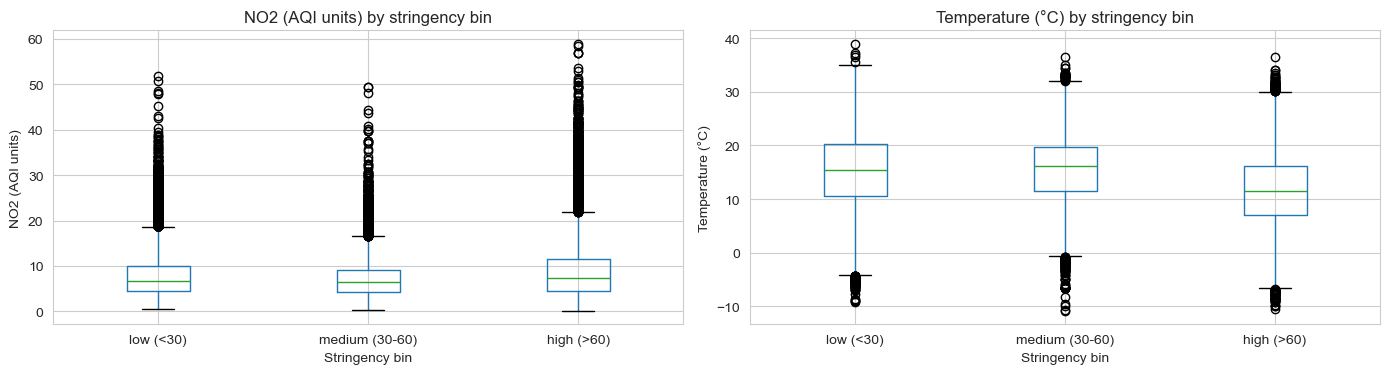

In [18]:
# Visualize NO2 and temperature distributions across stringency bins
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, var, label in [
    (axes[0], 'no2',         'NO2 (AQI units)'),
    (axes[1], 'temperature', 'Temperature (°C)'),
]:
    if var in df_panel.columns:
        df_panel.boxplot(column=var, by='stringency_bin', ax=ax)
        ax.set_title(f'{label} by stringency bin')
        ax.set_xlabel('Stringency bin')
        ax.set_ylabel(label)
        plt.sca(ax)
        plt.suptitle('')

plt.tight_layout()
plt.savefig('../output/figures/common_support.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 3.10 Feature engineering

We create additional variables useful for the analysis:

- **Log transformations** of pollutants (right-skewed distributions, following
  our Airbnb assignment's approach to prices)
- **Time variables**: day-of-week, month, year, week number (for fixed effects)
- **Lagged stringency** (policy effects may not be immediate)

In [19]:
# Log transformations for pollutants (add 1 to handle zeros)
# Air quality measures are typically right-skewed; logs make distributions
# more symmetric and coefficients interpretable as elasticities.
for col in pollutants:
    if col in df_panel.columns:
        df_panel[f'ln_{col}'] = np.log(df_panel[col].clip(lower=0) + 1)
        # Replace any remaining inf/-inf with NaN
        df_panel[f'ln_{col}'] = df_panel[f'ln_{col}'].replace([np.inf, -np.inf], np.nan)

print('Log-transformed pollutant columns added:', [c for c in df_panel.columns if c.startswith('ln_')])

Log-transformed pollutant columns added: ['ln_no2', 'ln_pm25', 'ln_pm10', 'ln_o3', 'ln_co', 'ln_so2']


In [20]:
# Time variables for fixed effects and seasonal controls
df_panel['year'] = df_panel['date'].dt.year
df_panel['month'] = df_panel['date'].dt.month
df_panel['week'] = df_panel['date'].dt.isocalendar().week.astype(int)
df_panel['dow'] = df_panel['date'].dt.dayofweek  # 0=Mon, 6=Sun
df_panel['yearmonth'] = df_panel['date'].dt.to_period('M').astype(str)
df_panel['yearweek'] = (df_panel['date'].dt.isocalendar().year.astype(str) + '-W'
                        + df_panel['date'].dt.isocalendar().week.astype(str).str.zfill(2))

print('Time variables added: year, month, week, dow, yearmonth, yearweek')

Time variables added: year, month, week, dow, yearmonth, yearweek


In [21]:
# Lagged stringency — policy effects on air quality are not instantaneous.
# Traffic adjusts over days, not hours. We create 7-day and 14-day lags.
df_panel = df_panel.sort_values(['City', 'date'])

for lag_days in [7, 14]:
    df_panel[f'stringency_lag{lag_days}'] = (
        df_panel.groupby('City')['stringency_index']
        .shift(lag_days)
    )

# 7-day rolling average of stringency (smooths daily noise in policy changes)
df_panel['stringency_7d_avg'] = (
    df_panel.groupby('City')['stringency_index']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

print('Lagged and smoothed stringency variables added.')

Lagged and smoothed stringency variables added.


---
## 3.11 Descriptive statistics

Summary statistics for the analysis-ready panel. We report for the full sample
and by country, following the tabular style from our previous assignments.

**Takeaway — Descriptive statistics and cross-country patterns:**

Several patterns stand out from the summary tables:

1. **Italy is an outlier in NO2.** Italian cities have a mean NO2 of ~16.5 AQI units — roughly **double** the sample-wide average (~8–9) and far above any other country. Italy also has the **highest mean stringency** (60.0), reflecting its early and severe lockdowns. This combination makes Italy a particularly interesting case: it has the most room to "respond" to lockdown-induced traffic reductions, but also the most confounders (Po Valley geography traps pollution, diesel vehicle fleet is older). We will need to check whether our results are driven by Italy alone.

2. **PM2.5 has an extreme maximum (832).** This is likely a monitoring anomaly or a short-lived pollution event (e.g., Saharan dust, wildfire smoke). While we do not drop it here — the log transformation and city fixed effects will dampen its influence — it is worth noting as a potential outlier.

3. **Stringency varies substantially both across and within countries** (mean 42.8, std 24.1, range 0–100). This is exactly the variation we need for identification: countries imposed, tightened, relaxed, and re-imposed restrictions at different times, giving us the cross-country and temporal variation that powers our difference-in-differences design.

4. **O3 (ozone) moves opposite to the other pollutants.** Its positive correlation with temperature and negative correlation with NO2 reflects the **NOx-O3 photochemical paradox**: when NO emissions drop (less traffic), there is less titration of ozone, so O3 concentrations *rise*. This is a well-documented atmospheric chemistry phenomenon and is consistent with what we would expect during lockdowns.

In [22]:
# Full-sample summary statistics
desc_cols = (
    ['stringency_index'] +
    pollutants +
    [f'ln_{p}' for p in pollutants if f'ln_{p}' in df_panel.columns] +
    [w for w in weather_vars if w in df_panel.columns]
)
desc_cols = [c for c in desc_cols if c in df_panel.columns]

summary = df_panel[desc_cols].describe().T
summary['missing_%'] = (df_panel[desc_cols].isna().mean() * 100).round(1)
summary = summary[['count', 'missing_%', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

print('Summary statistics — full sample:')
print(summary.to_string())

Summary statistics — full sample:
                     count  missing_%     mean    std     min      25%      50%      75%      max
stringency_index  115708.0        0.0    48.64  24.81    0.00    23.15    51.39    70.37    93.52
no2               111786.0        3.4     8.23   5.38    0.10     4.50     6.90    10.60    58.90
pm25               98111.0       15.2    36.25  20.33    1.00    21.00    32.00    48.00   832.00
pm10              114643.0        0.9    15.74   8.89    1.00    10.00    14.00    19.00   454.00
o3                101334.0       12.4    22.19   9.83    0.10    16.10    22.40    28.10   113.10
co                 53748.0       53.5     0.79   1.56    0.10     0.10     0.10     0.40    38.30
so2                67323.0       41.8     1.73   1.64    0.10     0.70     1.60     2.10   148.80
ln_no2            111786.0        3.4     2.08   0.53    0.10     1.70     2.07     2.45     4.09
ln_pm25            98111.0       15.2     3.48   0.53    0.69     3.09     3.50     

In [23]:
# Summary by country — mean values of key variables
key_vars = ['stringency_index', 'no2', 'pm25', 'o3', 'temperature']
key_vars = [c for c in key_vars if c in df_panel.columns]

by_country = df_panel.groupby('country_name')[key_vars].agg(['mean', 'std']).round(1)
by_country.columns = [f'{v}_{stat}' for v, stat in by_country.columns]

# Add city count
by_country['n_cities'] = df_panel.groupby('country_name')['City'].nunique()
by_country['n_obs'] = df_panel.groupby('country_name')['date'].count()

print('Summary by country:')
print(by_country.to_string())

Summary by country:
                stringency_index_mean  stringency_index_std  no2_mean  no2_std  pm25_mean  pm25_std  o3_mean  o3_std  temperature_mean  temperature_std  n_cities  n_obs
country_name                                                                                                                                                            
Austria                          54.3                  17.9       8.7      4.1       38.4      19.5      NaN     NaN              11.5              7.6         5   4780
Belgium                          45.1                  21.4       7.6      4.0       35.7      20.9     20.0     8.9              12.7              6.2         6   5547
Czechia                          38.8                  22.1       7.2      3.2       45.9      23.0     19.9     9.5              11.8              7.2         5   4510
France                           48.9                  25.5       7.2      4.5       34.7      18.6     22.5     9.4              13.9 

---
## 3.12 Visualizations

### 3.12.1 Distribution of key variables

We check the distributions of our primary outcome (NO2) and treatment (stringency)
variables to understand their shape and justify any transformations.

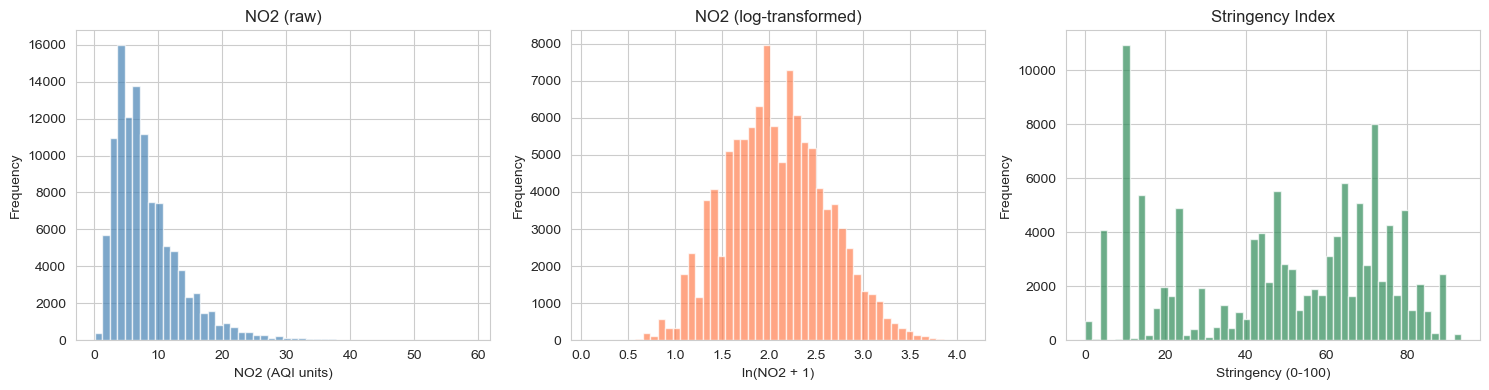

In [24]:
# Distribution of NO2 — raw and log-transformed
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if 'no2' in df_panel.columns:
    df_panel['no2'].dropna().hist(bins=50, ax=axes[0], color='steelblue', alpha=0.7)
    axes[0].set_title('NO2 (raw)')
    axes[0].set_xlabel('NO2 (AQI units)')

if 'ln_no2' in df_panel.columns:
    df_panel['ln_no2'].dropna().hist(bins=50, ax=axes[1], color='coral', alpha=0.7)
    axes[1].set_title('NO2 (log-transformed)')
    axes[1].set_xlabel('ln(NO2 + 1)')

df_panel['stringency_index'].dropna().hist(bins=50, ax=axes[2], color='seagreen', alpha=0.7)
axes[2].set_title('Stringency Index')
axes[2].set_xlabel('Stringency (0-100)')

for ax in axes:
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('../output/figures/distributions.png', bbox_inches='tight')
plt.show()

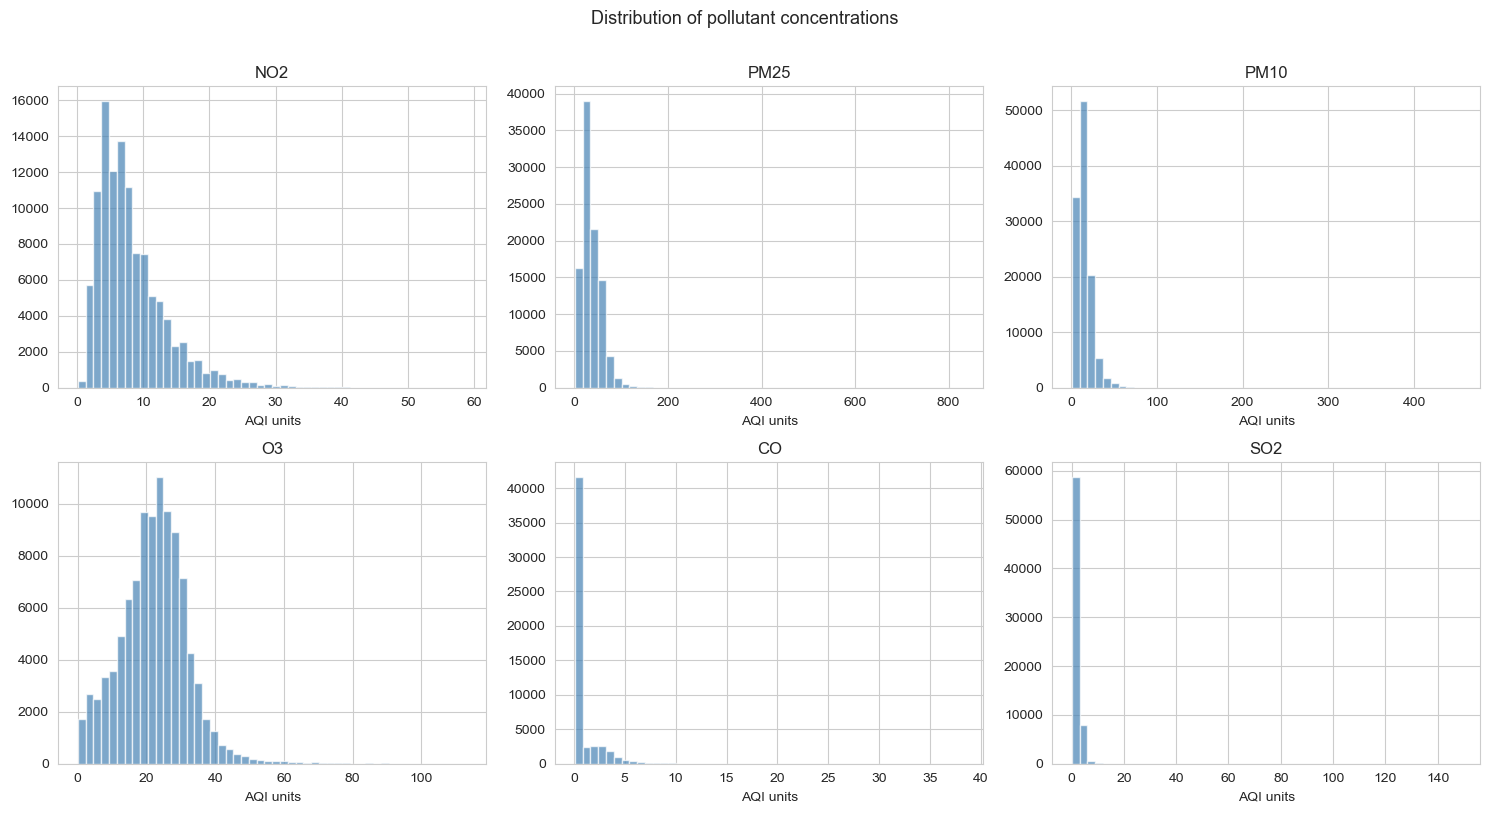

In [25]:
# Distributions of all pollutants
n_polls = len(pollutants)
fig, axes = plt.subplots(2, (n_polls + 1) // 2, figsize=(15, 8))
axes = axes.flatten()

for i, pol in enumerate(pollutants):
    if pol in df_panel.columns:
        df_panel[pol].dropna().hist(bins=50, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(pol.upper())
        axes[i].set_xlabel('AQI units')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of pollutant concentrations', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../output/figures/pollutant_distributions.png', bbox_inches='tight')
plt.show()

### 3.12.2 Time series: stringency and NO2 over time

We plot the average stringency index and NO2 across all cities over time.
This gives a first visual impression of whether lockdowns coincide with drops
in pollution — the core of our research question.

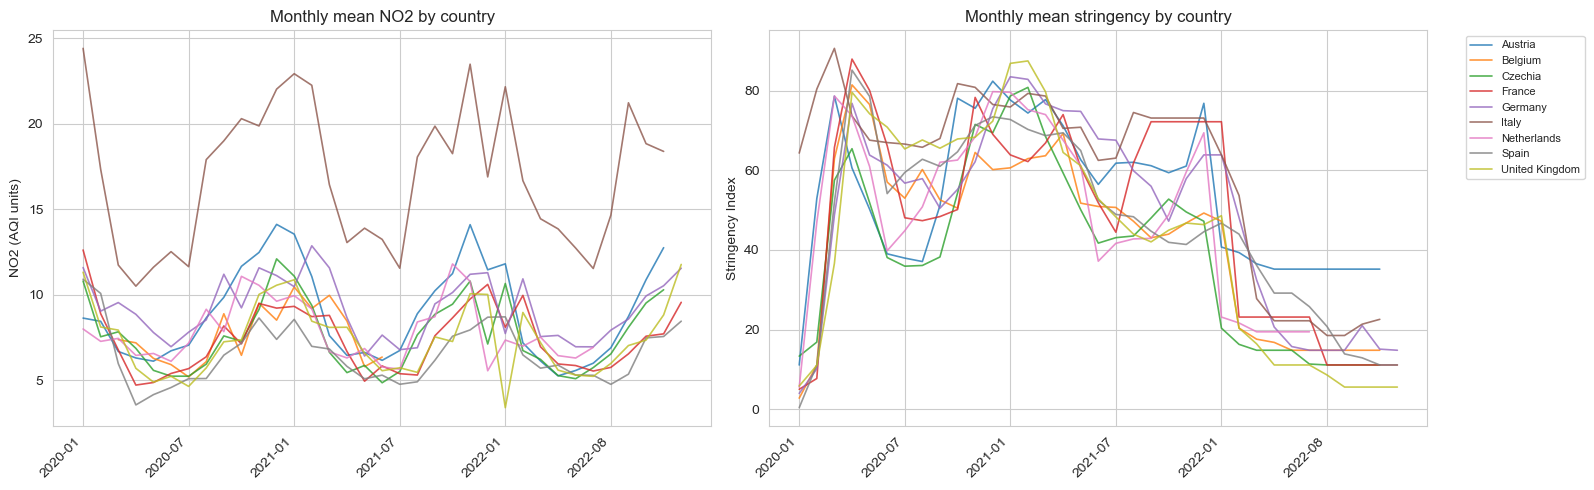

In [26]:
# Time series by country — shows the cross-country variation we exploit
# (Following the treatment/control group plotting style from our DiD assignments)
monthly_country = df_panel.groupby(['country_name', 'yearmonth']).agg(
    no2_mean=('no2', 'mean'),
    stringency_mean=('stringency_index', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for country in sorted(df_panel['country_name'].unique()):
    sub = monthly_country[monthly_country['country_name'] == country]
    axes[0].plot(range(len(sub)), sub['no2_mean'], linewidth=1.2, label=country, alpha=0.8)
    axes[1].plot(range(len(sub)), sub['stringency_mean'], linewidth=1.2, label=country, alpha=0.8)

axes[0].set_title('Monthly mean NO2 by country')
axes[0].set_ylabel('NO2 (AQI units)')
axes[1].set_title('Monthly mean stringency by country')
axes[1].set_ylabel('Stringency Index')

for ax in axes:
    n_months = len(monthly_country['yearmonth'].unique())
    tick_pos = range(0, n_months, 6)
    months = sorted(monthly_country['yearmonth'].unique())
    ax.set_xticks(list(tick_pos))
    ax.set_xticklabels([months[i] for i in tick_pos], rotation=45, ha='right')

axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../output/figures/timeseries_by_country.png', bbox_inches='tight')
plt.show()

**Takeaway — Time series by country:**

The NO2 panel reveals a clear **seasonal cycle** in every country (winter peaks, summer troughs), but **Italy stands out** with a distinctly higher level and more pronounced seasonal swings. While most countries' NO2 levels cluster between 5–15 AQI units, Italy's cities consistently sit at 15–25+. This gap persists across the entire 2020–2022 period, suggesting it reflects structural differences (vehicle fleet composition, urban density, Po Valley topography) rather than a data quality issue.

On the stringency side, the right panel shows the cross-country variation that identifies our model: **Italy and Spain locked down earliest and hardest** (spring 2020). The staggered timing of restrictions across countries — with waves of tightening and relaxation hitting at slightly different times.

Visually, the first lockdown (spring 2020) coincides with a noticeable NO2 dip across most countries, even relative to the normal seasonal decline. Whether this holds up after controlling for weather and seasonality is the question for the regression analysis.

**Takeaway — Seasonality and implications for model specification:**

The seasonality plot confirms a strong **U-shaped annual cycle** in NO2: concentrations are highest in winter (November–January) and lowest in summer (June–August). This pattern reflects:
- **Heating emissions** in winter (residential gas/oil heating)
- **Atmospheric stability** — cold winter air traps pollutants near the surface (temperature inversions)
- **Reduced photochemical destruction** of NO2 in winter (less sunlight)

This seasonality is a **critical confounder** for our analysis. The first major European lockdowns (March–May 2020) happened precisely during the seasonal decline in NO2. Without controlling for seasonality, we would overestimate the lockdown effect by attributing the normal spring improvement to policy.

Our model addresses this through:
1. **Week-of-year fixed effects** — absorb the average seasonal pattern
2. **Temperature controls** — capture year-specific weather variation beyond the seasonal mean
3. **City fixed effects** — absorb any city-specific level differences (like Italy's higher baseline)

This combination allows us to isolate the *additional* NO2 reduction caused by stringency beyond what seasonality and weather would predict.

### 3.12.3 Correlation matrix

We check the pairwise correlations between pollutants, weather, and the
stringency index. This helps identify:
- **Confounders**: if temperature is correlated with both stringency and NO2,
  we must control for it
- **Multicollinearity**: if two pollutants are very highly correlated (>0.9),
  we may not need both as outcomes

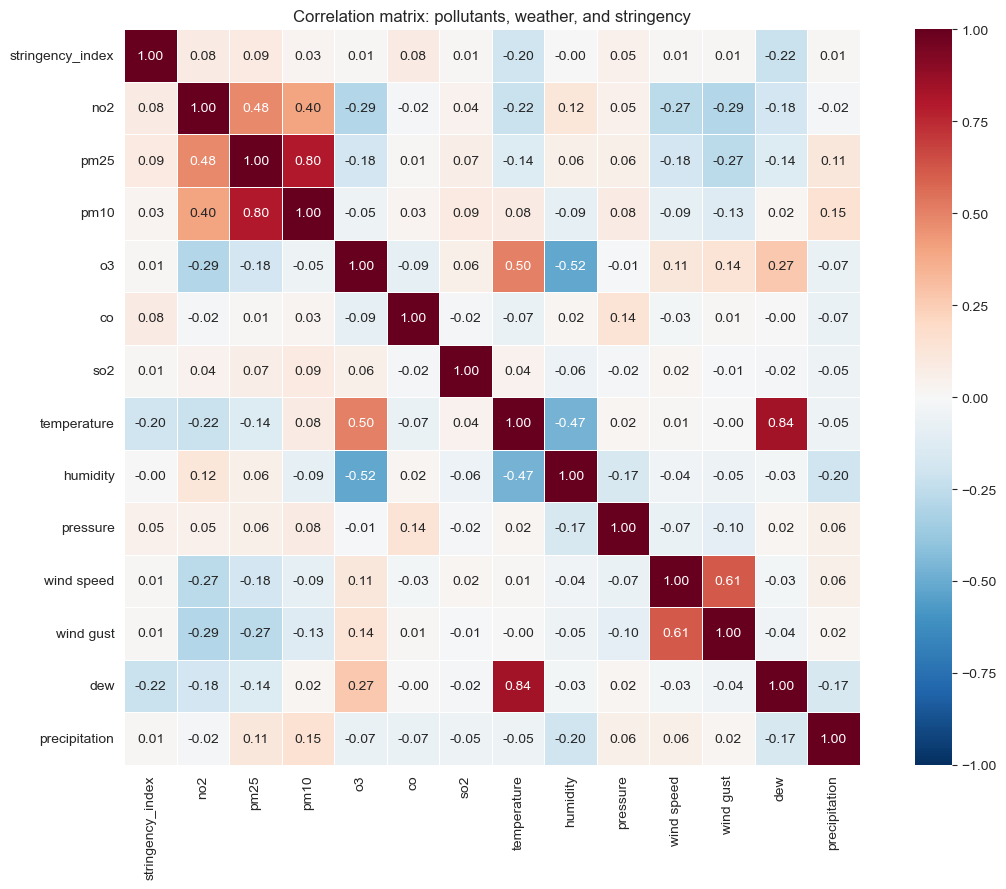

In [27]:
corr_vars = ['stringency_index'] + pollutants + weather_vars
corr_vars = [c for c in corr_vars if c in df_panel.columns]

corr_matrix = df_panel[corr_vars].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix, annot=True, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, fmt='.2f', square=True, ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation matrix: pollutants, weather, and stringency')
plt.tight_layout()
plt.savefig('../output/figures/correlation_matrix.png', bbox_inches='tight')
plt.show()

**Takeaway — Correlation matrix and weather control selection:**

The correlation matrix informs our choice of **weather control variables** for the regression:

**Why we cannot use precipitation:** As noted in Section 3.4, precipitation is ~95% missing across the sample. It is simply unusable. This is unfortunate since rainfall is a known mechanism for "washing out" particulate matter. However, the remaining weather variables provide good coverage of the main meteorological channels:

**Weather controls we will use:**
- **Temperature** (corr with NO2 ≈ −0.40): Strong negative correlation — warmer weather reduces heating demand and improves atmospheric mixing, lowering NO2. Also correlated with stringency (lockdowns coincided with winter/spring transitions), making it a critical confounder.
- **Humidity** (corr with NO2 ≈ +0.15): Moderate positive correlation — humid conditions can trap pollutants near the surface. Also partially captures the precipitation channel we cannot measure directly.
- **Pressure** (corr with NO2 ≈ +0.10): High-pressure systems create stable atmospheres that trap pollution. Low pressure brings wind and rain that disperses it.
- **Wind speed** (corr with NO2 ≈ −0.20): Directly disperses pollutants. Mechanically important and not collinear with the other weather variables.

**Variables we exclude:**
- **Dew point**: Highly collinear with temperature (corr > 0.9). Including both would create multicollinearity without adding independent information.
- **Wind gust**: Collinear with wind speed. The sustained wind speed is more relevant for average daily pollution levels.

Together, temperature, humidity, pressure, and wind speed capture the four main meteorological channels (thermal mixing, moisture, atmospheric stability, and mechanical dispersion) that affect air quality. This is a standard set in the environmental economics literature.

### 3.12.4 Scatter: stringency vs NO2

A simple scatter of stringency vs NO2 (aggregated to city × month to reduce
noise). This is purely descriptive — causal inference comes in the analysis
notebook — but it shows the raw relationship.

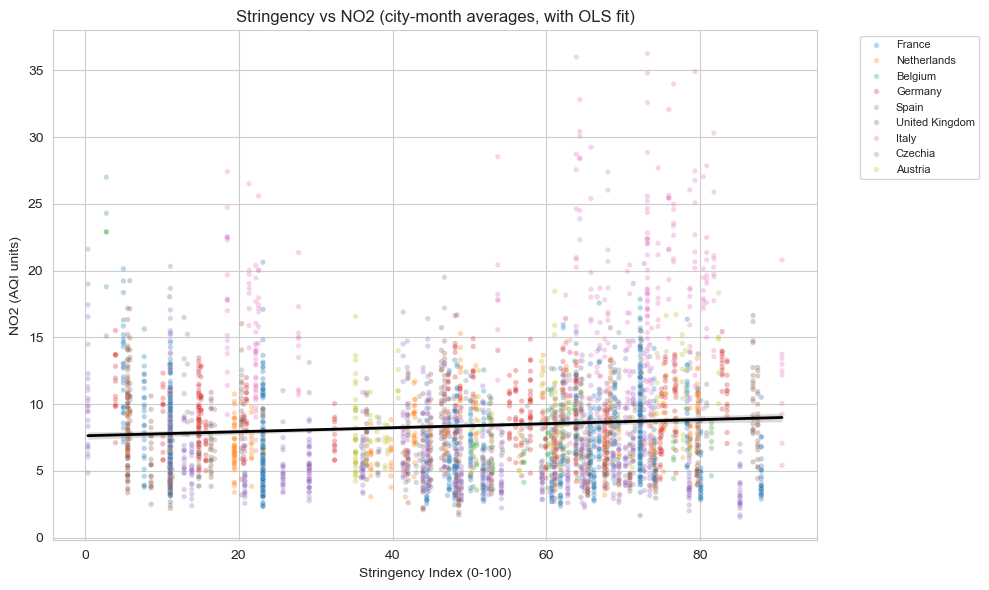

In [28]:
if 'no2' in df_panel.columns:
    scatter_data = df_panel.groupby(['City', 'yearmonth']).agg(
        no2=('no2', 'mean'),
        stringency=('stringency_index', 'mean'),
        country=('country_name', 'first')
    ).reset_index().dropna()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.scatterplot(
        data=scatter_data, x='stringency', y='no2',
        hue='country', alpha=0.3, s=15, ax=ax, legend='brief'
    )
    sns.regplot(
        data=scatter_data, x='stringency', y='no2',
        scatter=False, color='black', line_kws={'linewidth': 2}, ax=ax
    )
    ax.set_xlabel('Stringency Index (0-100)')
    ax.set_ylabel('NO2 (AQI units)')
    ax.set_title('Stringency vs NO2 (city-month averages, with OLS fit)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig('../output/figures/scatter_stringency_no2.png', bbox_inches='tight')
    plt.show()

### 3.12.5 Seasonality check

Air quality has strong seasonal patterns (heating in winter, ozone formation
in summer). We plot average NO2 by month-of-year to quantify this — it's a
key confounder we must control for in the analysis.

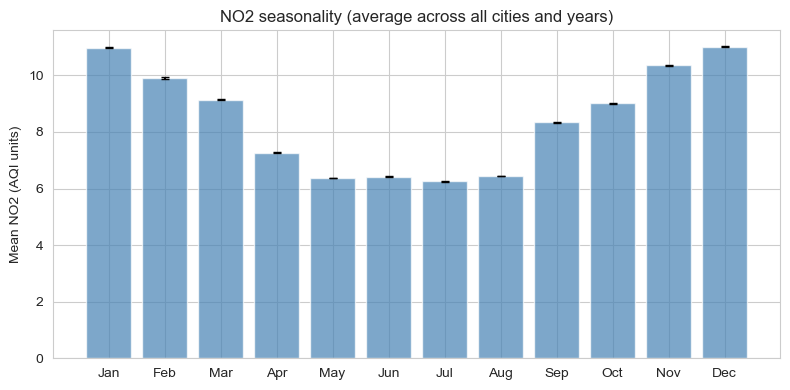

In [29]:
if 'no2' in df_panel.columns:
    seasonal = df_panel.groupby('month')['no2'].agg(['mean', 'std']).reset_index()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(seasonal['month'], seasonal['mean'], color='steelblue', alpha=0.7,
           yerr=seasonal['std'] / np.sqrt(len(df_panel)), capsize=3)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_ylabel('Mean NO2 (AQI units)')
    ax.set_title('NO2 seasonality (average across all cities and years)')
    plt.tight_layout()
    plt.savefig('../output/figures/no2_seasonality.png', bbox_inches='tight')
    plt.show()

---
## 3.13 Save analysis-ready dataset

In [30]:
output_path = '../data/clean/panel_city_day.csv'
df_panel.to_csv(output_path, index=False)

print(f'Saved analysis-ready panel: {output_path}')
print(f'  Rows:      {len(df_panel):,}')
print(f'  Columns:   {len(df_panel.columns)}')
print(f'  Cities:    {df_panel["City"].nunique()}')
print(f'  Countries: {df_panel["Country"].nunique()}')
print(f'  Date range: {df_panel["date"].min().date()} to {df_panel["date"].max().date()}')
print(f'\nKey columns:')
print(f'  Outcome: {[c for c in df_panel.columns if c in pollutants or c.startswith("ln_")]}')
print(f'  Treatment: stringency_index, stringency_lag7, stringency_lag14, stringency_7d_avg')
print(f'  Controls: {weather_vars}')
print(f'  FE vars: City, country_name, year, month, week, dow, yearweek')
print(f'\nReady for analysis in notebook 4.')

Saved analysis-ready panel: ../data/clean/panel_city_day.csv
  Rows:      115,708
  Columns:   52
  Cities:    120
  Countries: 9
  Date range: 2020-01-02 to 2022-12-31

Key columns:
  Outcome: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'ln_no2', 'ln_pm25', 'ln_pm10', 'ln_o3', 'ln_co', 'ln_so2']
  Treatment: stringency_index, stringency_lag7, stringency_lag14, stringency_7d_avg
  Controls: ['temperature', 'humidity', 'pressure', 'wind speed', 'wind gust', 'dew', 'precipitation']
  FE vars: City, country_name, year, month, week, dow, yearweek

Ready for analysis in notebook 4.
